### Two-Stage Parameter Finding (Hard-Coded Analysis)

This analysis reports the results of a hard-coded grid exploration over the main hyperparameters of the two-stage strategy.  
The procedure required approximately **6+ hours of runtime** and is intended as a **preliminary sanity check** prior to automated hyperparameter optimization (e.g., Optuna).

The goal is not fine-grained tuning, but to verify the **existence and stability of a performance peak**, as well as to analyze the trade-off between rule purity, rule support, and coverage.

---

#### Representative Configurations (Top Results)

| C   | min_rule_purity | min_rule_support | macro_f1 | rule_coverage |
|-----|------------------|------------------|----------|---------------|
| 1.0 | 0.95 | 40 | 0.721355 | 0.156438 |
| 1.0 | 0.95 | 30 | 0.721355 | 0.161562 |
| 1.0 | 0.95 | 20 | 0.721128 | 0.171750 |
| 1.0 | 0.90 | 30 | 0.720412 | 0.188812 |
| 1.0 | 0.90 | 40 | 0.720392 | 0.178375 |
| 1.0 | 0.90 | 20 | 0.720165 | 0.201625 |
| 0.5 | 0.95 | 30 | 0.719764 | 0.161562 |
| 0.5 | 0.95 | 40 | 0.719716 | 0.156438 |
| 0.5 | 0.95 | 20 | 0.719514 | 0.171750 |
| 1.5 | 0.95 | 40 | 0.719498 | 0.156438 |

---

#### Best Configuration (Preliminary Peak)

The analysis highlights a stable performance peak around the following configuration:

- **C** = 1.0  
- **min_rule_purity** = 0.95  
- **min_rule_support** = 40  
- **macro_f1** ≈ 0.721  
- **rule_coverage** ≈ 0.156  

This indicates that approximately **15–20% of the test split dataset** can be confidently handled by the deterministic stage, while the remaining samples are delegated to the probabilistic classifier.

---

#### Key Observations

- When rule purity reaches **0.95**, variations in rule support mainly affect **rule coverage**, with **negligible impact on macro F1**.
- The Top-10 configurations lie within a **narrow performance band**, suggesting that the two-stage approach is **structurally robust** rather than sensitive to fine hyperparameter tuning.
- The statistical relevance of the two-stage strategy is supported not only by the final evaluation metric, but also by its **consistent and interpretable coverage** of near-deterministic cases.

Overall, this hard-coded analysis confirms the validity of the two-stage design and motivates its use as a stable intermediate paradigm between linear baselines and fully semantic models.

#### Trade-off Analysis and Optimization Strategy

The hard-coded parameter exploration highlights the existence of a clear trade-off between the regularization parameter **C**, the minimum rule purity, and the minimum rule support. Higher purity thresholds enforce stricter deterministic rules, reducing noise but also limiting coverage, while lower support values increase rule coverage at the cost of reduced statistical reliability.

Empirically, variations in **C** and **min_rule_support** affect performance only at the level of a few decimal points in macro F1, indicating a relatively flat optimum region rather than a sharp maximum. In this regime, manual tuning becomes inefficient and sensitive to small validation fluctuations.

For this reason, automated hyperparameter optimization (Optuna) is employed in subsequent experiments to more efficiently explore the parameter space and refine the trade-off between precision and coverage within the identified stability region.


In [2]:
# Libraries and Frameworks
import pandas as pd
import numpy as np
import re
import itertools
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay


In [2]:
DEV_PATH = "../data/processed/development_processed.csv"
NUM_COLS = [
	"n_tokens",
	"title_len",
	"article_len",
	"title_ratio"
]

C_VALUES = [0.5, 1.0, 1.5, 2.0]

MIN_RULE_PURITY_V  = [0.85, 0.90, 0.95]
MIN_RULE_SUPPORT_V = [20, 30, 40]

# Fixed TF-IDF parameters (chosen a priori)
WORD_NG_MAX = 2
CHAR_NG_MAX = 5
MIN_DF      = 2
MAX_DF      = 0.9

In [3]:
df_dev = pd.read_csv(DEV_PATH)

X = df_dev[["source", "text"] + NUM_COLS]
y = df_dev["label"].values

X_tr, X_va, y_tr, y_va = train_test_split(
	X, y,
	test_size=0.2,
	stratify=y,
	random_state=42
)

print("Train size:", X_tr.shape[0])
print("Val size:", X_va.shape[0])


Train size: 63997
Val size: 16000


In [4]:
def tokenize_for_rules(text):
	if not isinstance(text, str):
		return []
	return re.findall(r"[a-z0-9_:/\.]+", text.lower())


In [5]:
def mine_pure_rules(texts, labels, MIN_RULE_SUPPORT, MIN_RULE_PURITY):
	counts = defaultdict(lambda: Counter())

	for txt, y in zip(texts, labels):
		for tok in set(tokenize_for_rules(txt)):
			counts[tok][int(y)] += 1

	rule_token_to_class = {}
	rule_meta = {}

	for tok, c in counts.items():
		total = sum(c.values())
		if total < MIN_RULE_SUPPORT:
			continue

		best_class, best_freq = c.most_common(1)[0]
		purity = best_freq / total

		if purity >= MIN_RULE_PURITY:
			rule_token_to_class[tok] = int(best_class)
			rule_meta[tok] = (purity, total)

	return rule_token_to_class, rule_meta


In [6]:
def apply_rules(texts, rule_token_to_class, rule_meta):
	rule_pred = np.full(len(texts), -1, dtype=int)

	for i, txt in enumerate(texts):
		toks = set(tokenize_for_rules(txt))
		hits = [t for t in toks if t in rule_token_to_class]
		if not hits:
			continue

		hits.sort(
			key=lambda t: (rule_meta[t][0], rule_meta[t][1]),
			reverse=True
		)

		rule_pred[i] = rule_token_to_class[hits[0]]

	return rule_pred


In [7]:
def make_model(C_VALUE):
	pre = ColumnTransformer(
		transformers=[
			("src", OneHotEncoder(handle_unknown="ignore"), ["source"]),
			("w_tfidf", TfidfVectorizer(
				analyzer="word",
				ngram_range=(1, WORD_NG_MAX),
				min_df=MIN_DF,
				max_df=MAX_DF,
				sublinear_tf=True,
				max_features=250_000
			), "text"),
			("c_tfidf", TfidfVectorizer(
				analyzer="char_wb",
				ngram_range=(3, CHAR_NG_MAX),
				min_df=MIN_DF,
				max_df=MAX_DF,
				sublinear_tf=True,
				max_features=300_000
			), "text"),
			("num", StandardScaler(), NUM_COLS),
		],
		remainder="drop",
		n_jobs=-1
	)

	clf = LogisticRegression(
		C=C_VALUE,
		class_weight="balanced",
		max_iter=2000,
		n_jobs=-1
	)

	return Pipeline([
		("pre", pre),
		("clf", clf),
	])


In [8]:

results = []

for C, purity, support in itertools.product(
	C_VALUES, MIN_RULE_PURITY_V, MIN_RULE_SUPPORT_V
):
	print(f"RUN → C={C}, purity={purity}, support={support}", flush=True)

	# Stage 2
	model = make_model(C)
	model.fit(X_tr, y_tr)
	ml_pred = model.predict(X_va)

	# Stage 1
	rules, meta = mine_pure_rules(
		df_dev.loc[X_tr.index, "text"],
		y_tr,
		support,
		purity
	)

	rule_pred = apply_rules(
		df_dev.loc[X_va.index, "text"],
		rules,
		meta
	)

	final_pred = ml_pred.copy()
	mask = rule_pred != -1
	final_pred[mask] = rule_pred[mask]

	f1 = f1_score(y_va, final_pred, average="macro")
	coverage = mask.mean()

	results.append({
		"C": C,
		"min_rule_purity": purity,
		"min_rule_support": support,
		"macro_f1": f1,
		"rule_coverage": coverage
	})


RUN → C=0.5, purity=0.85, support=20
RUN → C=0.5, purity=0.85, support=30
RUN → C=0.5, purity=0.85, support=40
RUN → C=0.5, purity=0.9, support=20
RUN → C=0.5, purity=0.9, support=30
RUN → C=0.5, purity=0.9, support=40
RUN → C=0.5, purity=0.95, support=20
RUN → C=0.5, purity=0.95, support=30
RUN → C=0.5, purity=0.95, support=40
RUN → C=1.0, purity=0.85, support=20
RUN → C=1.0, purity=0.85, support=30
RUN → C=1.0, purity=0.85, support=40
RUN → C=1.0, purity=0.9, support=20
RUN → C=1.0, purity=0.9, support=30
RUN → C=1.0, purity=0.9, support=40
RUN → C=1.0, purity=0.95, support=20
RUN → C=1.0, purity=0.95, support=30
RUN → C=1.0, purity=0.95, support=40
RUN → C=1.5, purity=0.85, support=20
RUN → C=1.5, purity=0.85, support=30
RUN → C=1.5, purity=0.85, support=40
RUN → C=1.5, purity=0.9, support=20
RUN → C=1.5, purity=0.9, support=30
RUN → C=1.5, purity=0.9, support=40
RUN → C=1.5, purity=0.95, support=20
RUN → C=1.5, purity=0.95, support=30
RUN → C=1.5, purity=0.95, support=40
RUN → C=2.

In [9]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("macro_f1", ascending=False)

df_results.head(10)

,C,min_rule_purity,min_rule_support,macro_f1,rule_coverage
17,1.0,0.95,40,0.721371,0.156438
16,1.0,0.95,30,0.721371,0.161562
15,1.0,0.95,20,0.721144,0.171750
13,1.0,0.90,30,0.720428,0.188812
14,1.0,0.90,40,0.720408,0.178375
12,1.0,0.90,20,0.720181,0.201625
7,0.5,0.95,30,0.719651,0.161562
8,0.5,0.95,40,0.719604,0.156438
6,0.5,0.95,20,0.719402,0.171750
26,1.5,0.95,40,0.719318,0.156438


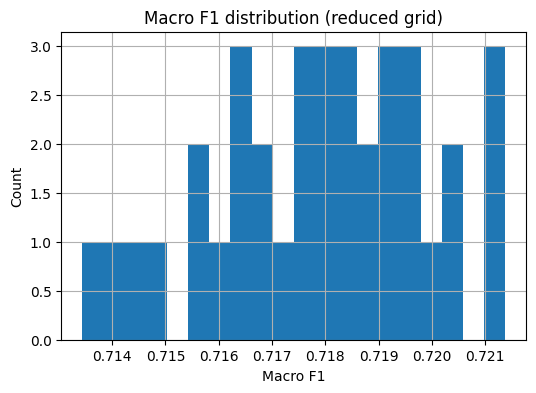

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df_results["macro_f1"], bins=20)
plt.xlabel("Macro F1")
plt.ylabel("Count")
plt.title("Macro F1 distribution (reduced grid)")
plt.grid(True)
plt.show()


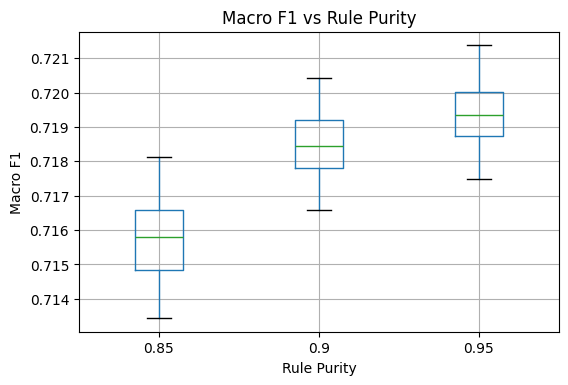

In [11]:
df_results.boxplot(column="macro_f1", by="min_rule_purity", figsize=(6,4))
plt.title("Macro F1 vs Rule Purity")
plt.suptitle("")
plt.xlabel("Rule Purity")
plt.ylabel("Macro F1")
plt.grid(True)
plt.show()


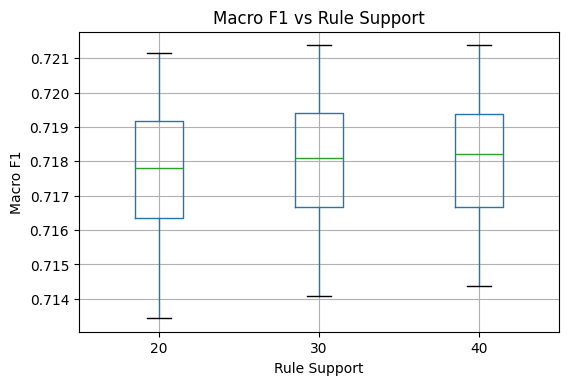

In [12]:
df_results.boxplot(column="macro_f1", by="min_rule_support", figsize=(6,4))
plt.title("Macro F1 vs Rule Support")
plt.suptitle("")
plt.xlabel("Rule Support")
plt.ylabel("Macro F1")
plt.grid(True)
plt.show()

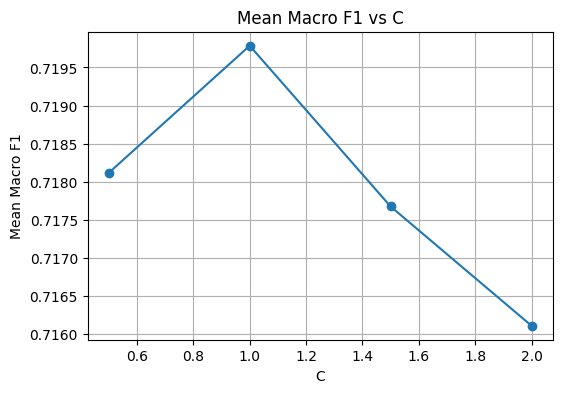

In [13]:
mean_f1_C = df_results.groupby("C")["macro_f1"].mean()

plt.figure(figsize=(6,4))
mean_f1_C.plot(marker="o")
plt.xlabel("C")
plt.ylabel("Mean Macro F1")
plt.title("Mean Macro F1 vs C")
plt.grid(True)
plt.show()

In [14]:
best = df_results.iloc[0]
print(best)

C                    1.000000
min_rule_purity      0.950000
min_rule_support    40.000000
macro_f1             0.721371
rule_coverage        0.156438
Name: 17, dtype: float64


In [15]:
best_model = make_model(best["C"])
best_model.fit(X_tr, y_tr)

rules, meta = mine_pure_rules(
	df_dev.loc[X_tr.index, "article"],
	y_tr,
	int(best["min_rule_support"]),
	float(best["min_rule_purity"])
)

pred = best_model.predict(X_va)
rule_pred = apply_rules(
	df_dev.loc[X_va.index, "article"],
	rules,
	meta
)

pred[rule_pred != -1] = rule_pred[rule_pred != -1]


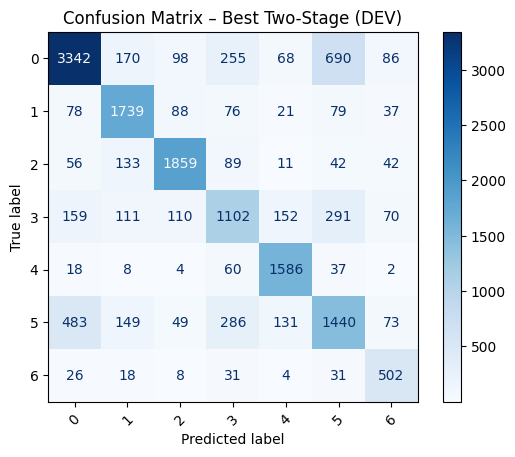

In [16]:
cm = confusion_matrix(y_va, pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix – Best Two-Stage (DEV)")
plt.show()

In [17]:
# Save results to CSV

df_results.to_csv("two_stage_grid_results.csv", index=False)

print(f"Results saved to two_stage_grid_results.csv")

Results saved to two_stage_grid_results.csv


In [3]:
df_results = pd.read_csv("two_stage_grid_results.csv")

In [19]:
df_results.columns

Index(['C', 'min_rule_purity', 'min_rule_support', 'macro_f1',
       'rule_coverage'],
      dtype='object')

C:\Users\msist\AppData\Local\Temp\ipykernel_33812\1597892801.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\msist\AppData\Local\Temp\ipykernel_33812\1597892801.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


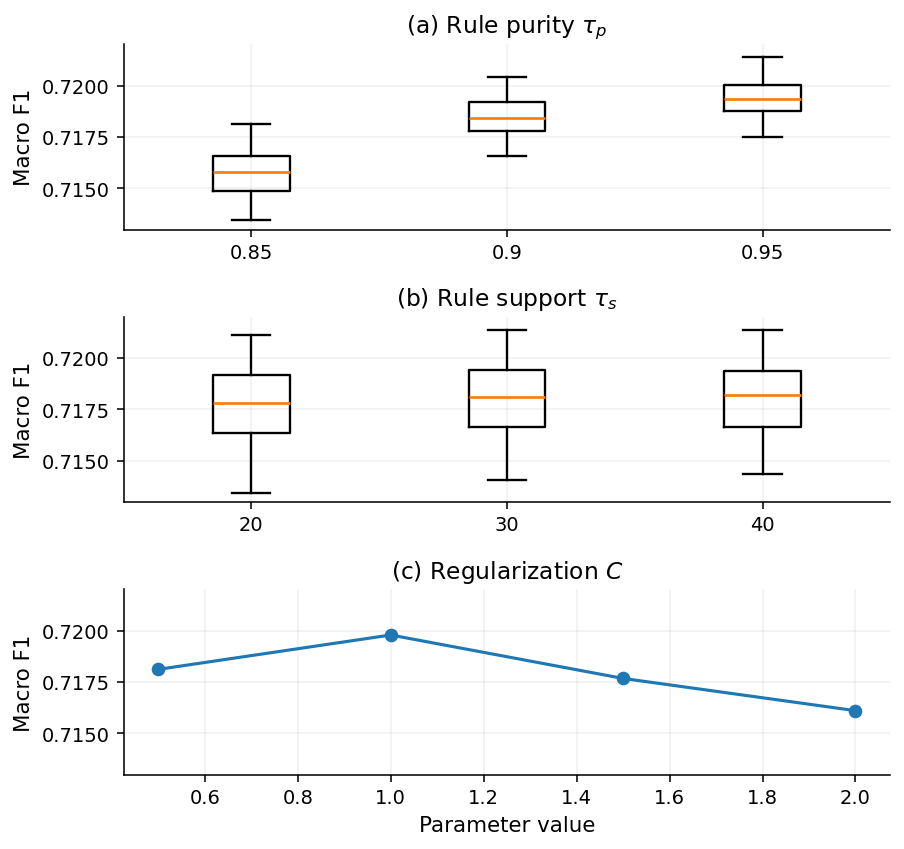

In [ ]:
import os
import matplotlib.pyplot as plt

# Matplotlib style (paper-ready)

plt.rcParams.update({
	"figure.dpi": 140,
	"savefig.dpi": 300,
	"font.size": 11,
	"axes.titlesize": 12,
	"axes.labelsize": 11,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.spines.top": False,
	"axes.spines.right": False,
	"axes.grid": True,
	"grid.alpha": 0.18,
	"grid.linewidth": 0.8,
})

# Output directory

os.makedirs("../figures", exist_ok=True)


# Figure setup

fig, axes = plt.subplots(
	3, 1,
	figsize=(6.5, 6.2),
	sharey=True
)

Y_LIM = (0.713, 0.722)

# ---- common box style ----
box_style = dict(
	boxprops=dict(linewidth=1.2),
	medianprops=dict(linewidth=1.4),
	whiskerprops=dict(linewidth=1.2),
	capprops=dict(linewidth=1.2),
	showfliers=False
)

# Rule purity τ_p — boxplot

purity_vals = sorted(df_results["min_rule_purity"].unique())
data_purity = [
	df_results.loc[df_results["min_rule_purity"] == p, "macro_f1"]
	for p in purity_vals
]

axes[0].boxplot(
	data_purity,
	labels=[str(p) for p in purity_vals],
	**box_style
)
axes[0].set_title(r"(a) Rule purity $\tau_p$")
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(*Y_LIM)


# Rule support τ_s — boxplot

support_vals = sorted(df_results["min_rule_support"].unique())
data_support = [
	df_results.loc[df_results["min_rule_support"] == s, "macro_f1"]
	for s in support_vals
]

axes[1].boxplot(
	data_support,
	labels=[str(s) for s in support_vals],
	**box_style
)
axes[1].set_title(r"(b) Rule support $\tau_s$")
axes[1].set_ylabel("Macro F1")


#Regularization C — line plot

C_vals = sorted(df_results["C"].unique())
mean_f1_C = [
	df_results.loc[df_results["C"] == c, "macro_f1"].mean()
	for c in C_vals
]

axes[2].plot(
	C_vals,
	mean_f1_C,
	marker="o",
	linewidth=1.6
)
axes[2].set_title(r"(c) Regularization $C$")
axes[2].set_xlabel("Parameter value")
axes[2].set_ylabel("Macro F1")


# Finalize

plt.tight_layout()
plt.savefig("../figures/twostage_sensitivity_mixed.png", dpi=300)
plt.show()


